Aim

To implement an advanced Convolutional Neural Network (CNN) using TensorFlow and Keras with Dropout layers for improved image classification performance.

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 248s 1us/step


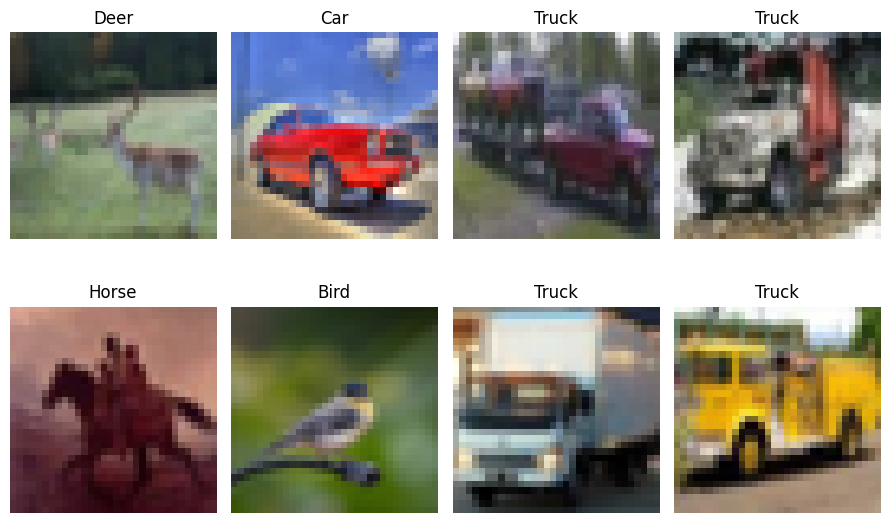

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 30, 30, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 15, 15, 32)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 15, 15, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 15, 15, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 13, 13, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 6, 6, 64)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 666,922 (2.54 MB)

 Trainable params: 666,730 (2.54 MB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/12
333/333 ━━━━━━━━━━━━━━━━━━━━ 220s 641ms/step - accuracy: 0.4294 - loss: 1.5653 - val_accuracy: 0.1539 - val_loss: 2.3330
Epoch 2/12
333/333 ━━━━━━━━━━━━━━━━━━━━ 266s 653ms/step - accuracy: 0.5728 - loss: 1.1982 - val_accuracy: 0.5604 - val_loss: 1.2718
Epoch 3/12
 10/333 ━━━━━━━━━━━━━━━━━━━━ 3:21 625ms/step - accuracy: 0.6022 - loss: 1.1301

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    AveragePooling2D,
    Dense,
    Flatten,
    Dropout,
    BatchNormalization
)

# Load Dataset
(train_x, train_y), (test_x, test_y) = cifar10.load_data()

# Normalize Images
train_x = train_x.astype("float32") / 255.0
test_x = test_x.astype("float32") / 255.0

# CIFAR-10 Labels
labels = [
    "Airplane",
    "Car",
    "Bird",
    "Cat",
    "Deer",
    "Dog",
    "Frog",
    "Horse",
    "Ship",
    "Truck"
]

# Display Images
plt.figure(figsize=(9,6))

for value in range(8):

    plt.subplot(2,4,value + 1)

    random_value = np.random.randint(0, 5000)

    plt.imshow(train_x[random_value])

    plt.title(
        labels[
            train_y[random_value][0]
        ]
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

# Build Deep CNN Model
deep_cnn = Sequential()

# CNN Block 1
deep_cnn.add(Conv2D(
    32,
    kernel_size=(3,3),
    padding='same',
    activation='relu',
    input_shape=(32,32,3)
))

deep_cnn.add(BatchNormalization())

deep_cnn.add(Conv2D(
    32,
    kernel_size=(3,3),
    activation='relu'
))

deep_cnn.add(AveragePooling2D(pool_size=(2,2)))

deep_cnn.add(Dropout(0.2))

# CNN Block 2
deep_cnn.add(Conv2D(
    64,
    kernel_size=(3,3),
    padding='same',
    activation='relu'
))

deep_cnn.add(BatchNormalization())

deep_cnn.add(Conv2D(
    64,
    kernel_size=(3,3),
    activation='relu'
))

deep_cnn.add(AveragePooling2D(pool_size=(2,2)))

deep_cnn.add(Dropout(0.3))

# CNN Block 3
deep_cnn.add(Conv2D(
    128,
    kernel_size=(3,3),
    activation='relu'
))

deep_cnn.add(Dropout(0.3))

# Flatten Layer
deep_cnn.add(Flatten())

# Fully Connected Layer
deep_cnn.add(Dense(
    256,
    activation='relu'
))

deep_cnn.add(Dropout(0.5))

# Output Layer
deep_cnn.add(Dense(
    10,
    activation='softmax'
))

# Model Information
deep_cnn.summary()

# Compile Model
deep_cnn.compile(
    optimizer='nadam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train Model
cnn_history = deep_cnn.fit(
    train_x,
    train_y,
    batch_size=128,
    epochs=12,
    validation_split=0.15,
    verbose=1
)

# Evaluate Model
cnn_loss, cnn_accuracy = deep_cnn.evaluate(
    test_x,
    test_y,
    verbose=0
)

print("\nFinal CNN Accuracy :", cnn_accuracy)

# Accuracy Plot
plt.figure(figsize=(7,5))

plt.plot(cnn_history.history['accuracy'])
plt.plot(cnn_history.history['val_accuracy'])

plt.title("CNN Accuracy Performance")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend([
    "Training Accuracy",
    "Validation Accuracy"
])

plt.show()

# Loss Plot
plt.figure(figsize=(7,5))

plt.plot(cnn_history.history['loss'])
plt.plot(cnn_history.history['val_loss'])

plt.title("CNN Loss Performance")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend([
    "Training Loss",
    "Validation Loss"
])

plt.show()

Conclusion

Successfully implemented an advanced CNN model using multiple convolution layers and dropout regularization for image classification on the CIFAR-10 dataset.